# Telecom Customer Churn & Retention
## 03 — Exploratory Data Analysis

The analysis focuses on:

- overall churn distribution;
- numerical differences between churned and retained customers;
- churn rates across contract, billing, demographic, and service categories;
- tenure and charge patterns;
- customer lifetime value (CLTV);
- relationships among numeric variables;
- historical churn reasons.

The goal is to identify the strongest patterns that should be investigated further in the modeling stage.

> **Important:** `Churn Score`, `Churn Label`, and `Churn Reason` are not predictive features. `Churn Reason` is used here only to describe why historical customers left.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 1. Load the cleaned dataset


In [2]:
candidate_paths = [
    Path("../data/processed/telco_churn_cleaned.csv"),
    Path("data/processed/telco_churn_cleaned.csv"),
    Path("telco_churn_cleaned.csv"),
    Path("/mnt/data/processed/telco_churn_cleaned.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "telco_churn_cleaned.csv was not found. "
        "Run 01_data_preparation.ipynb first."
    )

df = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Loaded: ../data/processed/telco_churn_cleaned.csv
Rows: 7,043
Columns: 33


In [3]:
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,"3,046.05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,"5,036.30",Yes,1,89,5340,Competitor had better devices


## 2. Set up figure output

In [5]:
if Path("../outputs").exists() or Path("..").resolve().name == "notebooks":
    FIGURE_DIR = Path("../outputs/figures")
else:
    FIGURE_DIR = Path("outputs/figures")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Figures will be saved to outputs/figures


## 3. Overall churn distribution

The target variable is `Churn Value`, where:

- `0` = retained customer
- `1` = churned customer


In [6]:
churn_summary = (
    df["Churn Value"]
    .value_counts()
    .rename(index={0: "Retained", 1: "Churned"})
    .to_frame("customers")
)

churn_summary["percentage"] = 100 * churn_summary["customers"] / len(df)
churn_summary


,customers,percentage
Churn Value,,
Retained,5174,73.46
Churned,1869,26.54


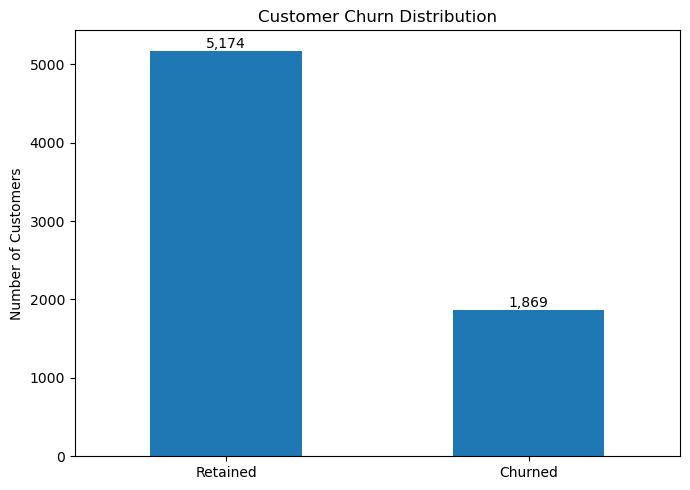

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

churn_summary["customers"].plot(kind="bar", ax=ax)

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(churn_summary["customers"]):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "churn_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Numerical profile: churned vs retained customers

This compares tenure, charges, and CLTV between the two customer groups.


In [8]:
numeric_profile = (
    df.groupby("Churn Label")[
        ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]
    ]
    .agg(["mean", "median"])
    .round(2)
)

numeric_profile


Tenure Months        Monthly Charges        Total Charges  \
                     mean median            mean median          mean   
Churn Label                                                             
No                  37.57  38.00           61.27  64.43      2,549.91   
Yes                 17.98  10.00           74.44  79.65      1,531.80   

                         CLTV           
              median     mean   median  
Churn Label                             
No          1,679.52 4,490.92 4,620.00  
Yes           703.55 4,149.41 4,238.00

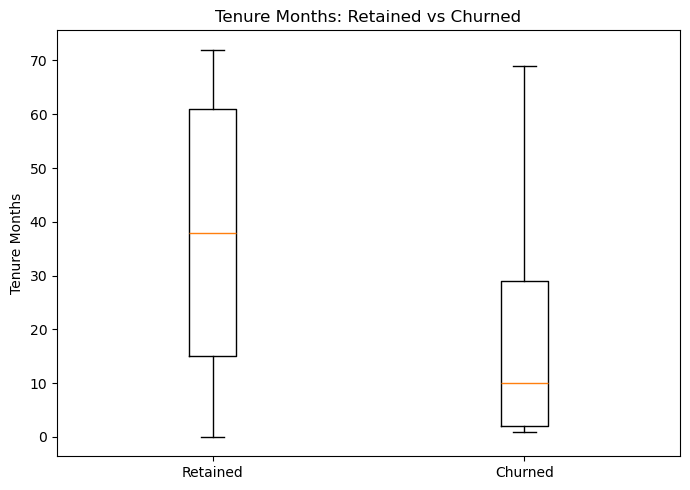

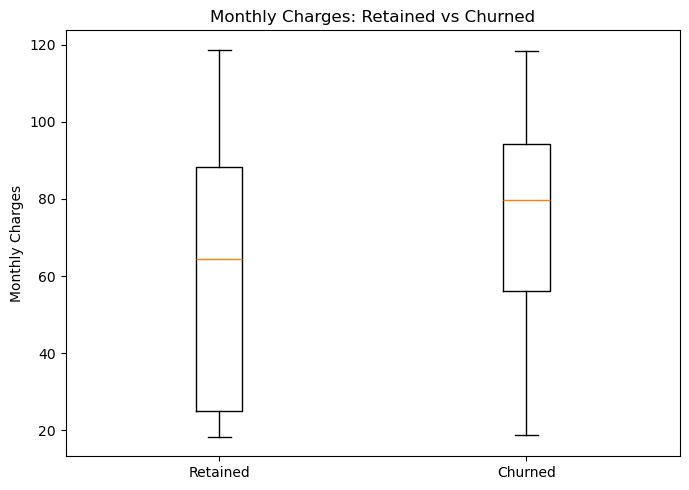

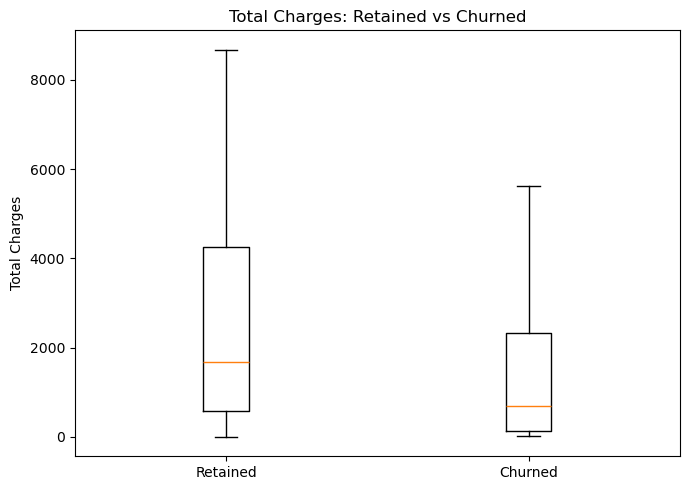

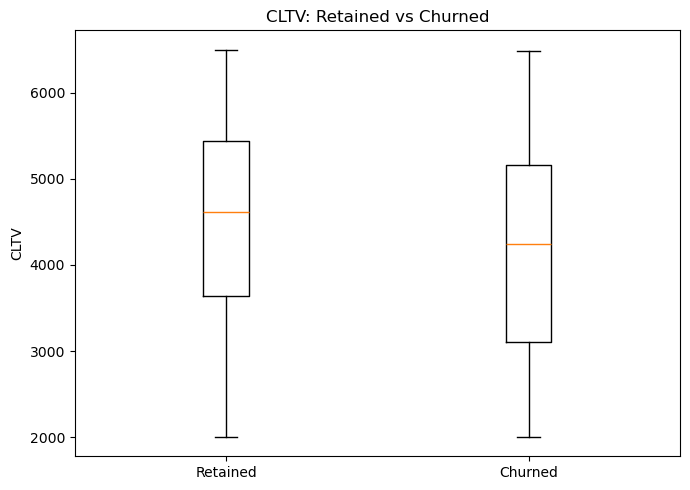

In [9]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

for feature in numeric_features:
    fig, ax = plt.subplots(figsize=(7, 5))

    retained = df.loc[df["Churn Value"] == 0, feature].dropna()
    churned = df.loc[df["Churn Value"] == 1, feature].dropna()

    ax.boxplot(
        [retained, churned],
        tick_labels=["Retained", "Churned"],
        showfliers=False
    )

    ax.set_title(f"{feature}: Retained vs Churned")
    ax.set_ylabel(feature)

    plt.tight_layout()

    filename = feature.lower().replace(" ", "_") + "_by_churn.png"
    plt.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


## 5. Churn by contract type

Contract structure is one of the most important business variables because it reflects customer commitment and switching flexibility.


In [10]:
contract_churn = (
    df.groupby("Contract")
    .agg(
        customers=("CustomerID", "count"),
        churned_customers=("Churn Value", "sum"),
        churn_rate=("Churn Value", "mean"),
    )
)

contract_churn["churn_rate_pct"] = 100 * contract_churn["churn_rate"]
contract_churn = contract_churn.sort_values("churn_rate_pct", ascending=False)

contract_churn[["customers", "churned_customers", "churn_rate_pct"]].round(2)


,customers,churned_customers,churn_rate_pct
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


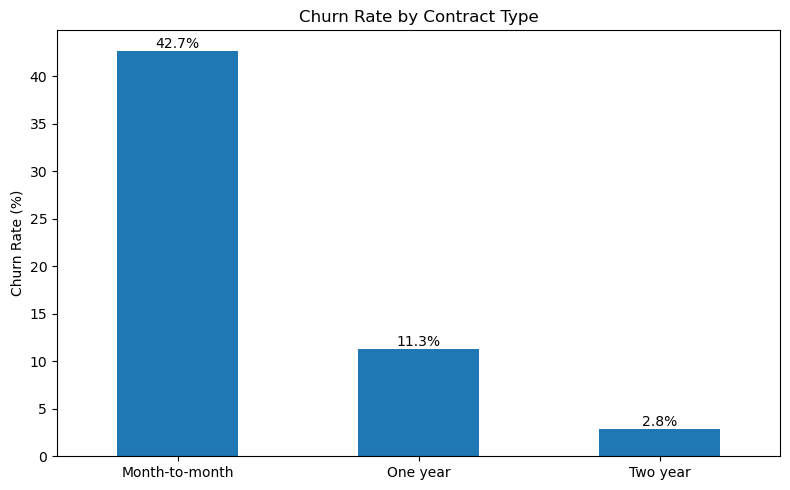

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

contract_churn["churn_rate_pct"].plot(kind="bar", ax=ax)

ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(contract_churn["churn_rate_pct"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "churn_by_contract.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Churn by tenure

Customers are grouped by length of relationship to understand when churn is most concentrated.


In [12]:
tenure_bins = [-1, 6, 12, 24, 48, np.inf]
tenure_labels = ["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49+ months"]

df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=tenure_bins,
    labels=tenure_labels
)

tenure_churn = (
    df.groupby("Tenure Group", observed=False)
    .agg(
        customers=("CustomerID", "count"),
        churned_customers=("Churn Value", "sum"),
        churn_rate=("Churn Value", "mean"),
    )
)

tenure_churn["churn_rate_pct"] = 100 * tenure_churn["churn_rate"]
tenure_churn[["customers", "churned_customers", "churn_rate_pct"]].round(2)


,customers,churned_customers,churn_rate_pct
Tenure Group,,,
0-6 months,1481,784,52.94
7-12 months,705,253,35.89
13-24 months,1024,294,28.71
25-48 months,1594,325,20.39
49+ months,2239,213,9.51


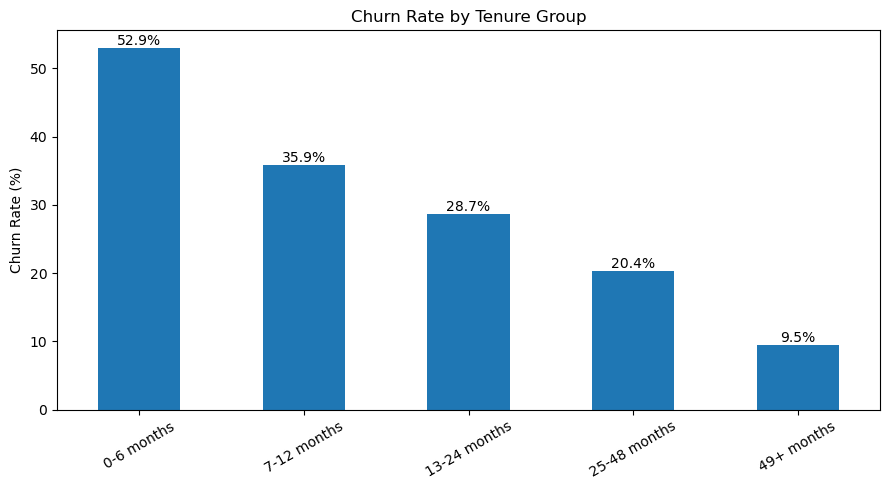

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

tenure_churn["churn_rate_pct"].plot(kind="bar", ax=ax)

ax.set_title("Churn Rate by Tenure Group")
ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
ax.tick_params(axis="x", rotation=30)

for i, value in enumerate(tenure_churn["churn_rate_pct"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "churn_by_tenure.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Churn by billing and payment behavior


,customers,churn_rate_pct
Payment Method,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24


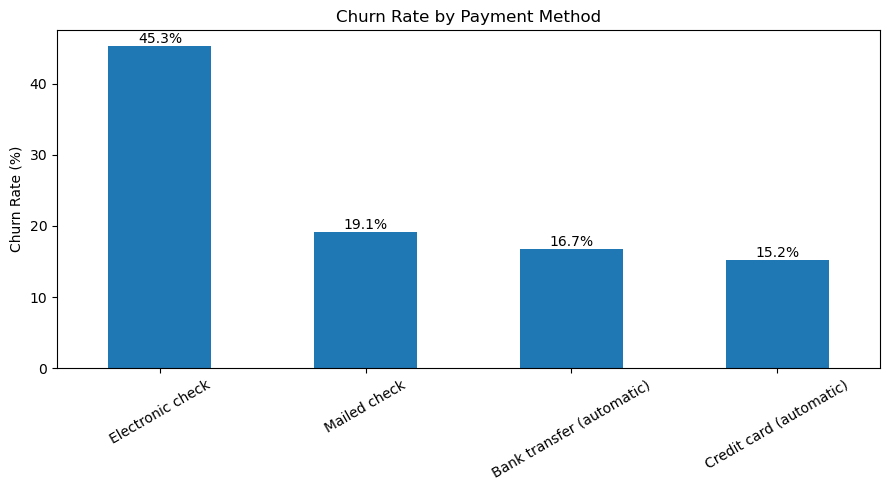

,customers,churn_rate_pct
Paperless Billing,,
Yes,4171,33.57
No,2872,16.33


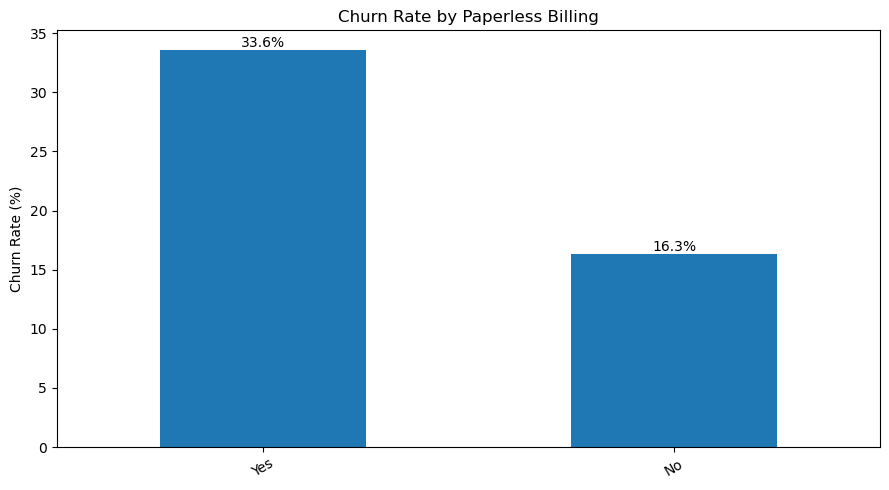

In [14]:
billing_variables = [
    "Payment Method",
    "Paperless Billing"
]

for variable in billing_variables:
    summary = (
        df.groupby(variable)
        .agg(
            customers=("CustomerID", "count"),
            churn_rate=("Churn Value", "mean")
        )
    )
    summary["churn_rate_pct"] = 100 * summary["churn_rate"]
    summary = summary.sort_values("churn_rate_pct", ascending=False)

    display(summary[["customers", "churn_rate_pct"]].round(2))

    fig, ax = plt.subplots(figsize=(9, 5))
    summary["churn_rate_pct"].plot(kind="bar", ax=ax)

    ax.set_title(f"Churn Rate by {variable}")
    ax.set_xlabel("")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=30)

    for i, value in enumerate(summary["churn_rate_pct"]):
        ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

    plt.tight_layout()

    filename = "churn_by_" + variable.lower().replace(" ", "_") + ".png"
    plt.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()


## 8. Churn by internet service


In [15]:
internet_churn = (
    df.groupby("Internet Service")
    .agg(
        customers=("CustomerID", "count"),
        churn_rate=("Churn Value", "mean"),
        avg_monthly_charges=("Monthly Charges", "mean")
    )
)

internet_churn["churn_rate_pct"] = 100 * internet_churn["churn_rate"]
internet_churn = internet_churn.sort_values("churn_rate_pct", ascending=False)

internet_churn[["customers", "churn_rate_pct", "avg_monthly_charges"]].round(2)


,customers,churn_rate_pct,avg_monthly_charges
Internet Service,,,
Fiber optic,3096,41.89,91.50
DSL,2421,18.96,58.10
No,1526,7.40,21.08


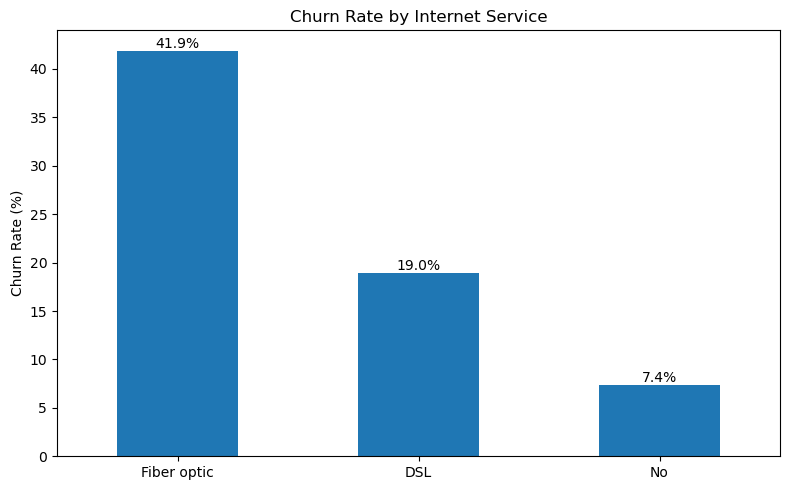

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

internet_churn["churn_rate_pct"].plot(kind="bar", ax=ax)

ax.set_title("Churn Rate by Internet Service")
ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(internet_churn["churn_rate_pct"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "churn_by_internet_service.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Churn by service features

Several add-on services may be associated with retention. For each feature, the table compares churn rates across service statuses.


In [17]:
service_features = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
]

service_results = []

for feature in service_features:
    temp = (
        df.groupby(feature)
        .agg(
            customers=("CustomerID", "count"),
            churn_rate=("Churn Value", "mean")
        )
        .reset_index()
    )

    temp["churn_rate_pct"] = 100 * temp["churn_rate"]
    temp.insert(0, "service", feature)
    temp = temp.rename(columns={feature: "status"})
    service_results.append(temp)

service_summary = pd.concat(service_results, ignore_index=True)

service_summary[
    ["service", "status", "customers", "churn_rate_pct"]
].round(2)


,service,status,customers,churn_rate_pct
0,Online Security,No,3498,41.77
1,Online Security,No internet service,1526,7.40
2,Online Security,Yes,2019,14.61
3,Online Backup,No,3088,39.93
4,Online Backup,No internet service,1526,7.40
5,Online Backup,Yes,2429,21.53
6,Device Protection,No,3095,39.13
7,Device Protection,No internet service,1526,7.40
8,Device Protection,Yes,2422,22.50
9,Tech Support,No,3473,41.64


In [18]:
# Compare churn rate for customers with versus without each service.
# "No internet service" is kept as a separate status rather than merged with "No".

pivot_service = service_summary.pivot(
    index="service",
    columns="status",
    values="churn_rate_pct"
)

pivot_service.round(2)


status,No,No internet service,Yes
service,,,
Device Protection,39.13,7.40,22.50
Online Backup,39.93,7.40,21.53
Online Security,41.77,7.40,14.61
Streaming Movies,33.68,7.40,29.94
Streaming TV,33.52,7.40,30.07
Tech Support,41.64,7.40,15.17


## 10. Demographic churn patterns


In [19]:
demographic_variables = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
]

demographic_results = []

for variable in demographic_variables:
    temp = (
        df.groupby(variable)
        .agg(
            customers=("CustomerID", "count"),
            churn_rate=("Churn Value", "mean")
        )
        .reset_index()
    )

    temp["churn_rate_pct"] = 100 * temp["churn_rate"]
    temp.insert(0, "variable", variable)
    temp = temp.rename(columns={variable: "group"})
    demographic_results.append(temp)

demographic_summary = pd.concat(demographic_results, ignore_index=True)

demographic_summary[
    ["variable", "group", "customers", "churn_rate_pct"]
].round(2)


,variable,group,customers,churn_rate_pct
0,Gender,Female,3488,26.92
1,Gender,Male,3555,26.16
2,Senior Citizen,No,5901,23.61
3,Senior Citizen,Yes,1142,41.68
4,Partner,No,3641,32.96
5,Partner,Yes,3402,19.66
6,Dependents,No,5416,32.55
7,Dependents,Yes,1627,6.52


## 11. Monthly charges and churn

Monthly price may interact with churn risk, particularly when combined with contract type or internet service.


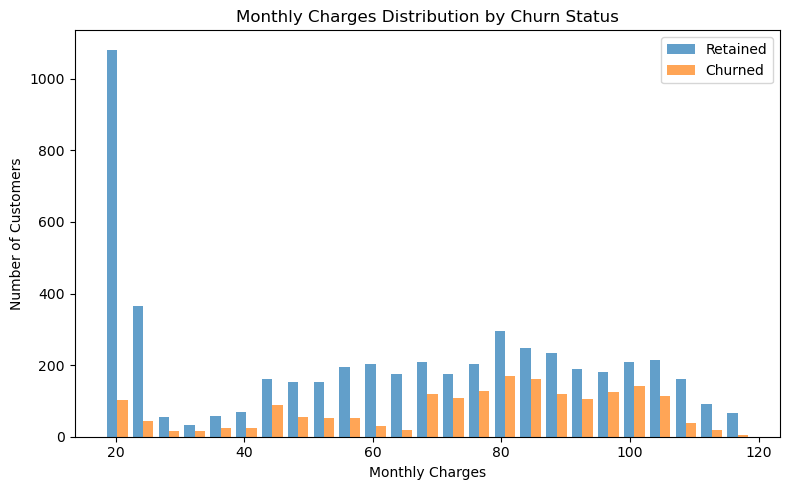

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [
        df.loc[df["Churn Value"] == 0, "Monthly Charges"],
        df.loc[df["Churn Value"] == 1, "Monthly Charges"]
    ],
    bins=25,
    label=["Retained", "Churned"],
    alpha=0.7
)

ax.set_title("Monthly Charges Distribution by Churn Status")
ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Number of Customers")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "monthly_charges_distribution_by_churn.png", dpi=200, bbox_inches="tight")
plt.show()


In [21]:
charge_bins = pd.qcut(
    df["Monthly Charges"],
    q=5,
    duplicates="drop"
)

charge_churn = (
    df.assign(Monthly_Charge_Group=charge_bins)
    .groupby("Monthly_Charge_Group", observed=False)
    .agg(
        customers=("CustomerID", "count"),
        churn_rate=("Churn Value", "mean")
    )
)

charge_churn["churn_rate_pct"] = 100 * charge_churn["churn_rate"]
charge_churn[["customers", "churn_rate_pct"]].round(2)


,customers,churn_rate_pct
Monthly_Charge_Group,,
"(18.249, 25.05]",1420,9.15
"(25.05, 58.83]",1397,24.98
"(58.83, 79.1]",1411,29.77
"(79.1, 94.25]",1407,36.11
"(94.25, 118.75]",1408,32.81


## 12. Customer Lifetime Value (CLTV)

CLTV is important for retention prioritization. A customer can have high churn risk but low value, or moderate churn risk and very high value.


In [22]:
cltv_summary = (
    df.groupby("Churn Label")
    .agg(
        customers=("CustomerID", "count"),
        avg_cltv=("CLTV", "mean"),
        median_cltv=("CLTV", "median"),
        avg_monthly_charges=("Monthly Charges", "mean"),
        avg_tenure_months=("Tenure Months", "mean")
    )
)

cltv_summary.round(2)


,customers,avg_cltv,median_cltv,avg_monthly_charges,avg_tenure_months
Churn Label,,,,,
No,5174,"4,490.92","4,620.00",61.27,37.57
Yes,1869,"4,149.41","4,238.00",74.44,17.98


In [23]:
df["CLTV Quartile"] = pd.qcut(
    df["CLTV"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"]
)

cltv_churn = (
    df.groupby("CLTV Quartile", observed=False)
    .agg(
        customers=("CustomerID", "count"),
        churn_rate=("Churn Value", "mean"),
        avg_cltv=("CLTV", "mean")
    )
)

cltv_churn["churn_rate_pct"] = 100 * cltv_churn["churn_rate"]
cltv_churn.round(2)


,customers,churn_rate,avg_cltv,churn_rate_pct
CLTV Quartile,,,,
Q1 - Lowest,1763,0.34,"2,743.63",34.43
Q2,1759,0.27,"4,079.81",26.83
Q3,1760,0.24,"4,959.76",24.15
Q4 - Highest,1761,0.21,"5,819.81",20.73


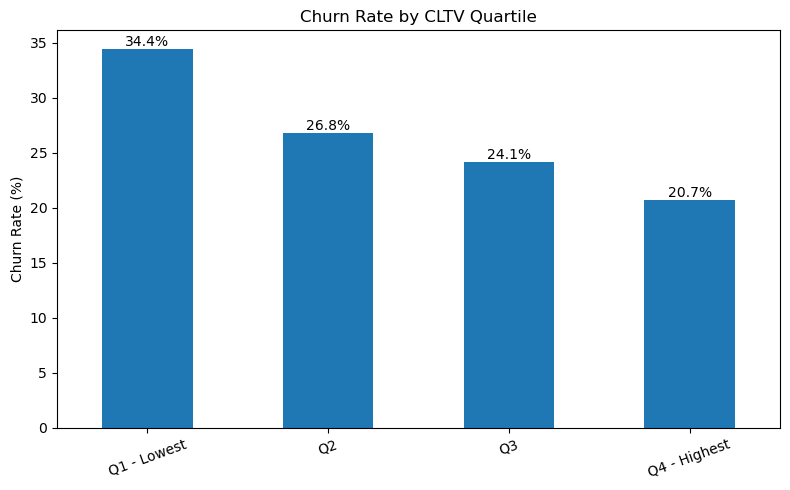

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

cltv_churn["churn_rate_pct"].plot(kind="bar", ax=ax)

ax.set_title("Churn Rate by CLTV Quartile")
ax.set_xlabel("")
ax.set_ylabel("Churn Rate (%)")
ax.tick_params(axis="x", rotation=20)

for i, value in enumerate(cltv_churn["churn_rate_pct"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "churn_by_cltv_quartile.png", dpi=200, bbox_inches="tight")
plt.show()


## 13. Numeric correlation analysis

Only numeric variables that could be meaningful for analysis are included. `Churn Score` is deliberately excluded because it is an existing churn-derived score.


In [25]:
correlation_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Churn Value",
]

corr = df[correlation_columns].corr()

corr.round(3)


,Tenure Months,Monthly Charges,Total Charges,CLTV,Churn Value
Tenure Months,1.00,0.25,0.83,0.40,-0.35
Monthly Charges,0.25,1.00,0.65,0.10,0.19
Total Charges,0.83,0.65,1.00,0.34,-0.20
CLTV,0.40,0.10,0.34,1.00,-0.13
Churn Value,-0.35,0.19,-0.20,-0.13,1.00


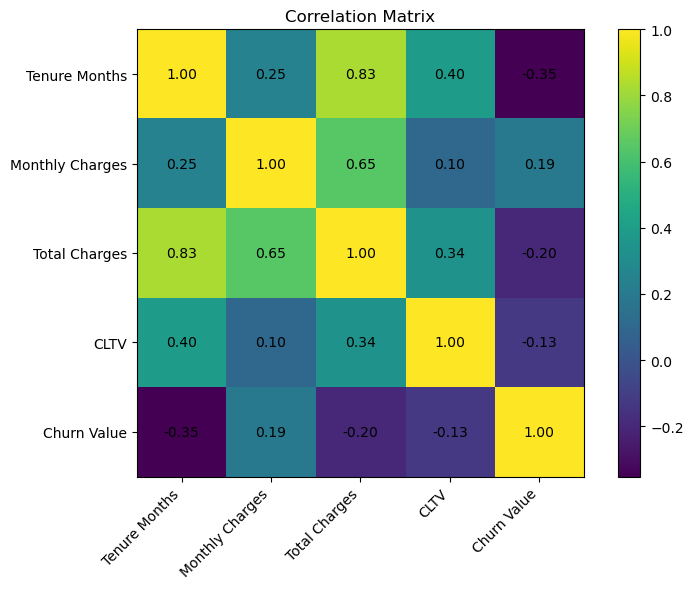

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr.values)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


## 14. Historical churn reasons

In [27]:
churn_reasons = (
    df.loc[
        (df["Churn Value"] == 1) & df["Churn Reason"].notna(),
        "Churn Reason"
    ]
    .value_counts()
    .to_frame("customers")
)

churn_reasons["percentage_of_churned"] = (
    100 * churn_reasons["customers"] / df["Churn Value"].sum()
)

churn_reasons.round(2)


,customers,percentage_of_churned
Churn Reason,,
Attitude of support person,192,10.27
Competitor offered higher download speeds,189,10.11
Competitor offered more data,162,8.67
Don't know,154,8.24
Competitor made better offer,140,7.49
Attitude of service provider,135,7.22
Competitor had better devices,130,6.96
Network reliability,103,5.51
Product dissatisfaction,102,5.46


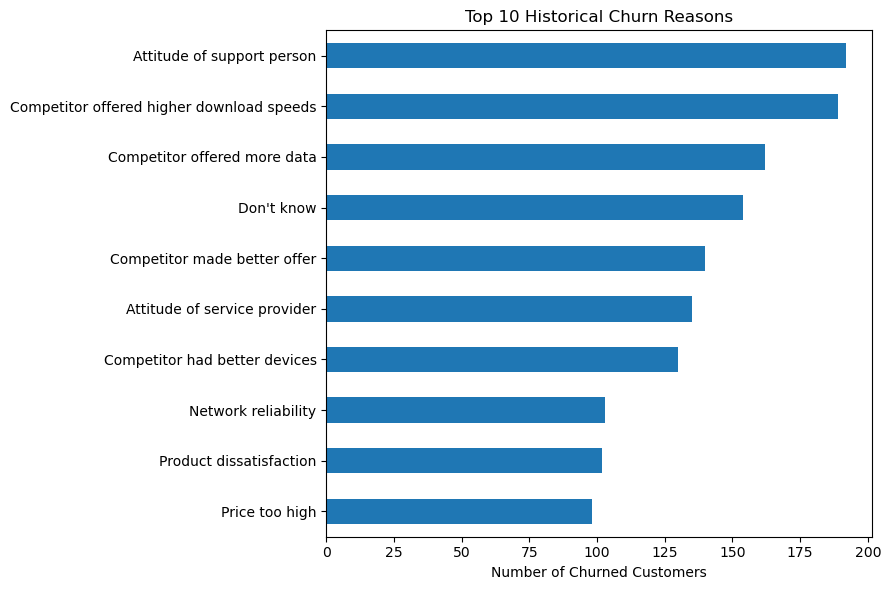

In [28]:
top_reasons = churn_reasons.head(10).sort_values("customers")

fig, ax = plt.subplots(figsize=(9, 6))

top_reasons["customers"].plot(kind="barh", ax=ax)

ax.set_title("Top 10 Historical Churn Reasons")
ax.set_xlabel("Number of Churned Customers")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_churn_reasons.png", dpi=200, bbox_inches="tight")
plt.show()


## 15. Key EDA findings table

In [29]:
overall_churn_rate = 100 * df["Churn Value"].mean()

highest_contract = contract_churn["churn_rate_pct"].idxmax()
highest_contract_rate = contract_churn.loc[highest_contract, "churn_rate_pct"]

highest_tenure = tenure_churn["churn_rate_pct"].idxmax()
highest_tenure_rate = tenure_churn.loc[highest_tenure, "churn_rate_pct"]

highest_payment_summary = (
    df.groupby("Payment Method")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
highest_payment = highest_payment_summary.index[0]
highest_payment_rate = highest_payment_summary.iloc[0]

highest_internet = internet_churn["churn_rate_pct"].idxmax()
highest_internet_rate = internet_churn.loc[highest_internet, "churn_rate_pct"]

eda_findings = pd.DataFrame({
    "finding": [
        "Overall churn rate",
        "Highest-churn contract type",
        "Highest-churn tenure group",
        "Highest-churn payment method",
        "Highest-churn internet service",
    ],
    "result": [
        f"{overall_churn_rate:.1f}%",
        f"{highest_contract} ({highest_contract_rate:.1f}%)",
        f"{highest_tenure} ({highest_tenure_rate:.1f}%)",
        f"{highest_payment} ({highest_payment_rate:.1f}%)",
        f"{highest_internet} ({highest_internet_rate:.1f}%)",
    ]
})

eda_findings


,finding,result
0,Overall churn rate,26.5%
1,Highest-churn contract type,Month-to-month (42.7%)
2,Highest-churn tenure group,0-6 months (52.9%)
3,Highest-churn payment method,Electronic check (45.3%)
4,Highest-churn internet service,Fiber optic (41.9%)
